In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


# Define physical constant 
q = 1.602192e-19                    # Elementary charge
epsilon0 = 8.854187817e-12          # Vaccum permittibity
nint = 1e10                         # Intrinsic carrier concentration
kB = 1.38065e-23                    # Boltzmann constant
T = 300.0                           # Temperature
VT = kB*T/q                         # Thermal Voltage  
Dp = 470.5e-4 * VT                  # Hole diffusion coefficient 
Dn = 1417e-4 * VT                   # Electron diffusion coefficient 

# Define Simulation variable  
L = 400e-9                          # Silicon Length  
N = 400                             # Number of grid points
ijunction = N // 2                  # Index of the PN Junction
l0 = L/N                            # Grid Spacing  
epsilon_si = 11.7                   # Silicon permittivity

# Define Doping parameters
ND = 1e17                           # Donor concentration
ND = ND * 1e6                       # Convert to /m^3
phiD = VT*math.asinh(0.5*ND/nint)   # Built-in Potential on N-side

NA = 1e17                           # Donor concentration
NA = NA * 1e6                       # Convert to /m^3
phiA = -VT*math.asinh(0.5*NA/nint)  # Built-in Potential on P-side

In [2]:
# Intialize spatial & doping vector
# Position vector 
x = np.arange(N+1) * L / N          

# Doping profile (ND on left, -NA on right)
dop = np.zeros((N+1, 1))            

dop[0:ijunction] = ND               
dop[ijunction:N+1] = -NA

In [ ]:
# Initial potential value using quasi-equilibrium condition
phi = np.zeros((N+1, 1))
for ii in range(0, N+1):
    phi[ii] = VT * math.asinh(0.5 * dop[ii] / nint)

# Initialize carrier densities (holes and electrons)
hole = np.zeros((N+1, 1))
elec = np.zeros((N+1, 1))

C:\Users\isang\AppData\Local\Temp\ipykernel_35004\2929108062.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phi[ii] = VT * math.asinh(0.5 * dop[ii] / nint)


In [4]:
# Newton-Raphson iteration loop
for inewton in range(1, 10):

    # System matrix A & RHS vector b
    A = np.zeros((3*(N+1), 3*(N+1)))
    b = np.zeros((3*(N+1), 1))

    for ii in range(1, N):
        # Discretized Poisson equation
        b[3*ii] = epsilon_si * (phi[ii+1] - phi[ii]) - epsilon_si * (phi[ii] - phi[ii-1])
        A[3*ii, 3*(ii-1)] = epsilon_si
        A[3*ii, 3*ii]     = -2 * epsilon_si
        A[3*ii, 3*(ii+1)] = epsilon_si

        # Hole concentration
        b[3*ii+1] = hole[ii]
        A[3*ii+1, 3*ii+1] = 1.0

        # Electron concentration 
        b[3*ii+2] = elec[ii]
        A[3*ii+2, 3*ii+2] = 1.0

        # Non-linear charge terms to Poisson equation
        b[3*ii] += q * (hole[ii] - elec[ii] + dop[ii]) / epsilon0 * l0**2
        A[3*ii, 3*ii+1] =  q / epsilon0 * l0**2  
        A[3*ii, 3*ii+2] = -q / epsilon0 * l0**2   

        # Update hole equation with Non-linear term
        b[3*ii+1] -= nint * math.exp(-phi[ii] / VT)
        A[3*ii+1, 3*ii] = nint / VT * math.exp(-phi[ii] / VT)

        # Update electron equation with Non-linear term
        b[3*ii+2] -= nint * math.exp(phi[ii] / VT)
        A[3*ii+2, 3*ii] = -nint / VT * math.exp(phi[ii] / VT)

  
    # Boundary conditions
    # Potential boundary
    b[0] = phi[0] - phiD
    A[0, 0] = 1.0
    b[3*N] = phi[N] - phiA
    A[3*N, 3*N] = 1.0

    # Hole boundary (left and right)
    b[1] = hole[0] - nint * math.exp(-phiD / VT)
    A[1, 1] = 1.0
    b[3*N+1] = hole[N] - nint * math.exp(-phiA / VT)
    A[3*N+1, 3*N+1] = 1.0

    # Electron boundary (left and right)
    b[2] = elec[0] - nint * math.exp(phiD / VT)
    A[2, 2] = 1.0
    b[3*N+2] = elec[N] - nint * math.exp(phiA / VT)
    A[3*N+2, 3*N+2] = 1.0

    
    # Linear system solving & Update Potential value
    update = np.linalg.solve(A, b)

    # Update variables
    phi  = phi  - update[range(0, 3*(N+1), 3)]
    hole = hole - update[range(1, 3*(N+1), 3)]
    elec = elec - update[range(2, 3*(N+1), 3)]

C:\Users\isang\AppData\Local\Temp\ipykernel_35004\2259201786.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b[3*ii+1] -= nint * math.exp(-phi[ii] / VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_35004\2259201786.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[3*ii+1, 3*ii] = nint / VT * math.exp(-phi[ii] / VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_35004\2259201786.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b[3*ii+2] -= nint * math.exp(

In [6]:
# Solve Drift-Diffusion with Continuity
for inewton in range(1,10):

    # Initialize Matrix
    A = np.zeros( (3*(N+1), 3*(N+1)) )
    b = np.zeros( (3*(N+1), 1      ) )  
    
    for ii in range(1,N):    

        # Discretized Poisson equation
        b[3*ii] = epsilon_si*(phi[ii+1]-phi[ii])-epsilon_si*(phi[ii]-phi[ii-1])
        A[3*ii,3*(ii-1)] = epsilon_si
        A[3*ii,3* ii   ] = -epsilon_si-epsilon_si
        A[3*ii,3*(ii+1)] = epsilon_si

        # Add charge density 
        b[3*ii] = b[3*ii] + q*(hole[ii]-elec[ii]+dop[ii])/epsilon0*l0*l0
        A[3*ii,3*ii+1] =  q/epsilon0*l0*l0
        A[3*ii,3*ii+2] = -q/epsilon0*l0*l0

        # Hole continuity equation (Drift-Diffusion)
        # Hole current density (direction : i -> i+1)
        b[3*ii+1] = -q*Dp/l0*( (hole[ii+1]-hole[ii]) + 0.5 * (hole[ii+1]+hole[ii]) * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+1,3*(ii+1)+1] = A[3*ii+1,3*(ii+1)+1] - q*Dp/l0*(  1.0 + 0.5 * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+1,3* ii   +1] = A[3*ii+1,3* ii   +1] - q*Dp/l0*( -1.0 + 0.5 * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+1,3*(ii+1)  ] = A[3*ii+1,3*(ii+1)  ] - q*Dp/l0*(  0.5 * (hole[ii+1]+hole[ii])/VT )
        A[3*ii+1,3* ii     ] = A[3*ii+1,3* ii     ] - q*Dp/l0*( -0.5 * (hole[ii+1]+hole[ii])/VT )
        
        # Hole current density (direction : i-1 <- i)
        b[3*ii+1] = b[3*ii+1] + q*Dp/l0*( (hole[ii]-hole[ii-1]) + 0.5 * (hole[ii]+hole[ii-1]) * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+1,3* ii   +1] = A[3*ii+1,3* ii   +1] + q*Dp/l0*(  1.0 + 0.5 * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+1,3*(ii-1)+1] = A[3*ii+1,3*(ii-1)+1] + q*Dp/l0*( -1.0 + 0.5 * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+1,3* ii     ] = A[3*ii+1,3* ii     ] + q*Dp/l0*(  0.5 * (hole[ii]+hole[ii-1])/VT )
        A[3*ii+1,3*(ii-1)  ] = A[3*ii+1,3*(ii-1)  ] + q*Dp/l0*( -0.5 * (hole[ii]+hole[ii-1])/VT )

        # Electron continuity equation (Drift-Diffusion)
        # Electron current density (direction : i -> i+1)
        b[3*ii+2] = q*Dn/l0*( (elec[ii+1]-elec[ii]) - 0.5 * (elec[ii+1]+elec[ii]) * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+2,3*(ii+1)+2] = A[3*ii+2,3*(ii+1)+2] + q*Dn/l0*(  1.0 - 0.5 * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+2,3* ii   +2] = A[3*ii+2,3* ii   +2] + q*Dn/l0*( -1.0 - 0.5 * (phi[ii+1]-phi[ii])/VT )
        A[3*ii+2,3*(ii+1)  ] = A[3*ii+2,3*(ii+1)  ] + q*Dn/l0*( -0.5 * (elec[ii+1]+elec[ii])/VT )
        A[3*ii+2,3* ii     ] = A[3*ii+2,3* ii     ] + q*Dn/l0*(  0.5 * (elec[ii+1]+elec[ii])/VT )       

        # Electron current density (direction : i-1 <- i)
        b[3*ii+2] = b[3*ii+2] - q*Dn/l0*( (elec[ii]-elec[ii-1]) - 0.5 * (elec[ii]+elec[ii-1]) * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+2,3* ii   +2] = A[3*ii+2,3* ii   +2] - q*Dn/l0*(  1.0 - 0.5 * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+2,3*(ii-1)+2] = A[3*ii+2,3*(ii-1)+2] - q*Dn/l0*( -1.0 - 0.5 * (phi[ii]-phi[ii-1])/VT )
        A[3*ii+2,3* ii     ] = A[3*ii+2,3* ii     ] - q*Dn/l0*( -0.5 * (elec[ii]+elec[ii-1])/VT )
        A[3*ii+2,3*(ii-1)  ] = A[3*ii+2,3*(ii-1)  ] - q*Dn/l0*(  0.5 * (elec[ii]+elec[ii-1])/VT )       
        
    # Boundary conditions
    # Potential boundary
    b[0] = phi[0] - phiD
    A[0,0] = 1.0
    b[3*N] = phi[N] - phiA
    A[3*N,3*N] = 1.0

    # Hole boundary (left and right)
    b[1] = hole[0] - nint*math.exp(-phiD/VT)
    A[1,1] = 1.0
    b[3*N+1] = hole[N] - nint*math.exp(-phiA/VT)
    A[3*N+1,3*N+1] = 1.0

    # Electron boundary (left and right)
    b[2] = elec[0] - nint*math.exp(phiD/VT)
    A[2,2] = 1.0
    b[3*N+2] = elec[N] - nint*math.exp(phiA/VT)
    A[3*N+2,3*N+2] = 1.0

    # Linear system solving & Update 
    update = np.linalg.solve(A, b)

    # Update variables
    phi  = phi  - update[range(0,3*(N+1),3)]
    hole = hole - update[range(1,3*(N+1),3)]
    elec = elec - update[range(2,3*(N+1),3)]


C:\Users\isang\AppData\Local\Temp\ipykernel_35004\1608869228.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[3*ii+1,3*(ii+1)+1] = A[3*ii+1,3*(ii+1)+1] - q*Dp/l0*(  1.0 + 0.5 * (phi[ii+1]-phi[ii])/VT )
C:\Users\isang\AppData\Local\Temp\ipykernel_35004\1608869228.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[3*ii+1,3* ii   +1] = A[3*ii+1,3* ii   +1] - q*Dp/l0*( -1.0 + 0.5 * (phi[ii+1]-phi[ii])/VT )
C:\Users\isang\AppData\Local\Temp\ipykernel_35004\1608869228.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array 

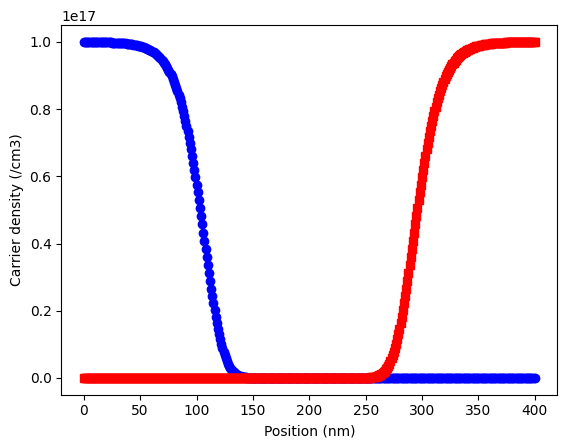

In [ ]:
plt.plot(x/1e-9,elec/1e6,'bo-')         # Electron density plot
plt.plot(x/1e-9,hole/1e6,'rs-')         # Hole density plot

plt.xlabel('Position (nm)')
plt.ylabel('Carrier density (/cm3)')

plt.show()